In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib as mpl
from matplotlib import pyplot as plt
import seaborn as sns
from matplotlib.ticker import FormatStrFormatter

from functions import *

palette = plt.cm.viridis
font = {'color':  'black', 'weight': 'normal','size': 14}
font_cb = {'color':  'black', 'weight': 'normal','size': 12}
labelsize=12

In [2]:
data = pd.read_csv('results/data.csv', index_col='Cluster')

new_masses, new_comp_masses = np.load('results/new_masses.npy'), np.load('results/new_comp_masses.npy')

In [3]:
m1 = data['mass'].values
m2 = data['comp_mass'].values
q=m2/m1

log_m1 = np.log10(m1)
log_m2 = np.log10(m2)

min_mass = min(log_m1.min(), log_m2[log_m2>0].min())
max_mass = log_m1.max()

mass_bins, P_prim, P_comp, P_BS = loop_probabilities(log_m1, log_m2, min_mass, max_mass, dm=0.05)

dP_prim_arr, dP_comp_arr, dP_BS_arr = [], [], []
for i in range(0,len(new_masses)):
    new_comp_masses[i][q ==0] = 0
    
    log_m1 = np.log10(new_masses[i])
    log_m2 = np.log10(new_comp_masses[i])
    mb, dP_prim, dP_comp, dP_BS = loop_probabilities(log_m1, log_m2, min_mass, max_mass, dm=0.05)
    dP_prim = np.interp(mass_bins, mb, dP_prim, left=np.nan, right=np.nan)
    dP_comp = np.interp(mass_bins, mb, dP_comp, left=np.nan, right=np.nan)
    dP_BS = np.interp(mass_bins, mb, dP_BS, left=np.nan, right=np.nan)

    dP_prim_arr.append(dP_prim)
    dP_comp_arr.append(dP_comp)
    dP_BS_arr.append(dP_BS)



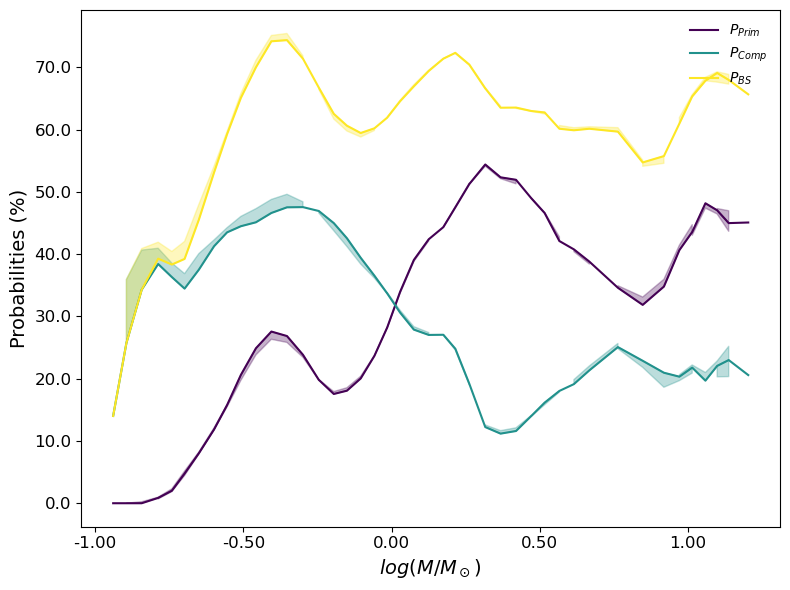

In [4]:
nominal_values = [P_prim, P_comp, P_BS]
standard_devs = [dP_prim_arr, dP_comp_arr, dP_BS_arr]

labels = [r'$P_{Prim}$', r'$P_{Comp}$', r'$P_{BS}$']
cmap = plt.cm.viridis
cores = cmap(np.linspace(0, 1, 3))


fig, axs = plt.subplots(figsize=(8,6))

for i in range(0, len(nominal_values)):
    axs.plot(mass_bins,  nominal_values[i]*100,label = labels[i], color = cores[i])    
    minimos = np.array([min(col) for col in zip(*standard_devs[i])])*100
    maximos = np.array([max(col) for col in zip(*standard_devs[i])])*100
    axs.fill_between(mass_bins, nominal_values[i]*100, maximos, alpha=0.3, color=cores[i], where = maximos>=nominal_values[i]*100)
    axs.fill_between(mass_bins, minimos, nominal_values[i]*100, alpha=0.3, color=cores[i], where = minimos<=nominal_values[i]*100)
    
axs.tick_params(labelleft=True, labelbottom=True, labelsize=labelsize)
axs.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
axs.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
    
axs.set_ylabel(r'Probabilities (%)', fontdict=font)
axs.set_xlabel(r'$log(M/M_\odot)$', fontdict=font)
plt.legend(loc='upper right',frameon=False)
plt.tight_layout()
plt.savefig('Figures/dist_fb_por_massa.png', dpi=300)
plt.show()



In [5]:
10**mass_bins

array([ 0.11511058,  0.12760138,  0.14365876,  0.16326501,  0.18155628,
        0.20044805,  0.22394451,  0.25195931,  0.27879495,  0.31034338,
        0.34879966,  0.3932648 ,  0.44380782,  0.50251561,  0.56833755,
        0.6383923 ,  0.70702081,  0.78661794,  0.87515285,  0.96596019,
        1.068058  ,  1.18870874,  1.33430536,  1.49452642,  1.64038752,
        1.82880714,  2.0695385 ,  2.33055673,  2.62766566,  2.95803919,
        3.28131848,  3.67969792,  4.1184298 ,  4.64392189,  5.79598251,
        7.02667543,  8.2832563 ,  9.34160167, 10.31910403, 11.43377306,
       12.52297429, 13.70047858, 15.94356824])

In [6]:
P_prim[np.argwhere(10**mass_bins>8)].mean()

np.float64(0.43482142721100014)

In [50]:
data = pd.read_csv('results/data.csv', index_col='Cluster')
new_masses, new_comp_masses = np.load('results/new_masses.npy'), np.load('results/new_comp_masses.npy')

m1 = data['mass'].values
m2 = data['comp_mass'].values
q = m2/m1

log_m1_bin = np.log10(m1[q>0])

min_mass = log_m1_bin.min()
max_mass = log_m1_bin.max()

mass_bins, qs = loop_mass_ratio(log_m1_bin, q[q>0], min_mass, max_mass, dm=0.05)

dq_arr = []
for i in range(0,len(new_masses)):
    
    log_m1_bin = np.log10(new_masses[i][q>0])
    q_ = new_comp_masses[i][q>0]/new_masses[i][q>0]

    min_mass = log_m1_bin.min()
    max_mass = log_m1_bin.max()
    
    mb, dq = loop_mass_ratio(log_m1_bin, q_, min_mass, max_mass, dm=0.05)
    dq = np.interp(mass_bins, mb, dq, left=np.nan, right=np.nan)

    dq_arr.append(dq)

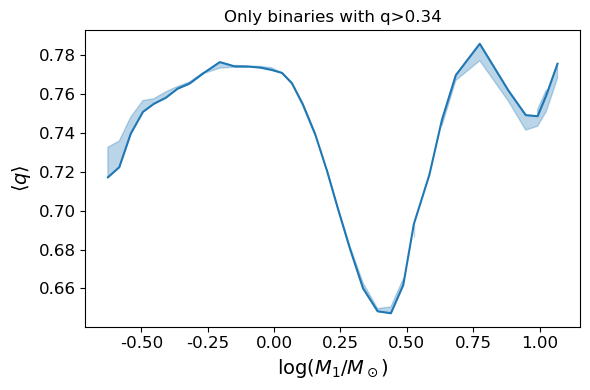

In [52]:
minimos = [min(col) for col in zip(*dq_arr)]
maximos = [max(col) for col in zip(*dq_arr)]

fig, axs = plt.subplots(figsize=(6,4))


axs.fill_between(mass_bins, qs, maximos, alpha=0.3, color='tab:blue', where = maximos>=qs)
axs.fill_between(mass_bins, minimos, qs, alpha=0.3, color='tab:blue', where = minimos<=qs)
axs.plot(mass_bins, qs)

axs.set_ylabel(r'$\langle q \rangle$', fontdict=font)
axs.set_xlabel(r'$\log(M_1/M_\odot)$', fontdict=font)
axs.tick_params(labelleft=True, labelbottom=True, labelsize=labelsize)
axs.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
axs.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
plt.title('Only binaries with q>0.34')
plt.tight_layout()
#plt.savefig('Figures/dist_q_por_massa.png', dpi=300)
plt.savefig('dist_q_por_massa_034.png', dpi=300)
plt.show() 

In [14]:
(10**mass_bins[np.argmin(qs)]).round(2)

np.float64(2.75)

In [15]:
data2 = pd.read_csv('Data/data.csv')

In [47]:
m1 = data2['mass'].values
m2 = data2['comp_mass'].values
q = m2/m1

log_m1_bin = np.log10(m1[q>0])

min_mass = log_m1_bin.min()
max_mass = log_m1_bin.max()

mass_bins, qs = loop_mass_ratio(log_m1_bin, q[q>0], min_mass, max_mass, dm=0.05)

dq_arr = []

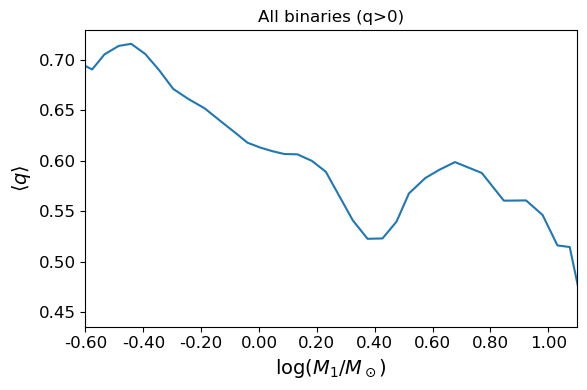

In [48]:
minimos = [min(col) for col in zip(*dq_arr)]
maximos = [max(col) for col in zip(*dq_arr)]

fig, axs = plt.subplots(figsize=(6,4))


#axs.fill_between(mass_bins, qs, maximos, alpha=0.3, color='tab:blue', where = maximos>=qs)
#axs.fill_between(mass_bins, minimos, qs, alpha=0.3, color='tab:blue', where = minimos<=qs)
axs.plot(mass_bins, qs)

axs.set_ylabel(r'$\langle q \rangle$', fontdict=font)
axs.set_xlabel(r'$\log(M_1/M_\odot)$', fontdict=font)
axs.tick_params(labelleft=True, labelbottom=True, labelsize=labelsize)
axs.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
axs.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
plt.title('All binaries (q>0)')
plt.tight_layout()
plt.xlim(-0.6, 1.1)

plt.savefig('dist_q_por_massa_all.png', dpi=300)
plt.show() 

In [21]:
np.log10(data.mass.min())

np.float64(-1.0411971696759512)

In [45]:
m1 = data2['mass'].values
m2 = data2['comp_mass'].values
q = m2/m1

log_m1_bin = np.log10(m1[q>0.6])

min_mass = log_m1_bin.min()
max_mass = log_m1_bin.max()

mass_bins, qs = loop_mass_ratio(log_m1_bin, q[q>0.6], min_mass, max_mass, dm=0.05)

dq_arr = []

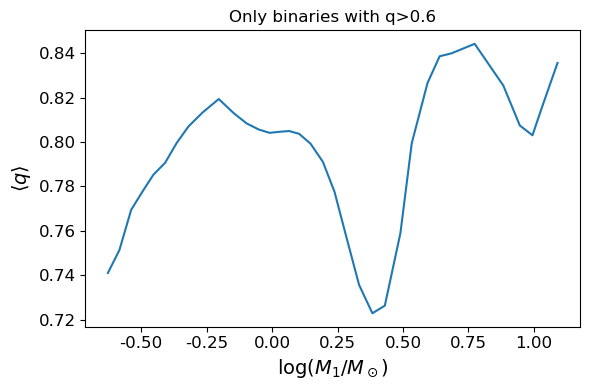

In [46]:
minimos = [min(col) for col in zip(*dq_arr)]
maximos = [max(col) for col in zip(*dq_arr)]

fig, axs = plt.subplots(figsize=(6,4))


#axs.fill_between(mass_bins, qs, maximos, alpha=0.3, color='tab:blue', where = maximos>=qs)
#axs.fill_between(mass_bins, minimos, qs, alpha=0.3, color='tab:blue', where = minimos<=qs)
axs.plot(mass_bins, qs)

axs.set_ylabel(r'$\langle q \rangle$', fontdict=font)
axs.set_xlabel(r'$\log(M_1/M_\odot)$', fontdict=font)
axs.tick_params(labelleft=True, labelbottom=True, labelsize=labelsize)
axs.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
axs.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
plt.title('Only binaries with q>0.6')
plt.tight_layout()
#plt.xlim(-0.6, 1.1)

plt.savefig('dist_q_por_massa_06.png', dpi=300)
plt.show() 